In [20]:
#import standard packages:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import sklearn.metrics as metrics
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy.stats import norm

#import modules from our method:
from lidglm import ExtendedGLM_Utils
from lidglm.extended_glm.transformer.Custom_Lipschitz.Custom_Lipschitz import Custom_InducedNormLinear
from lidglm.extended_glm.extended_glm_eval_utls import Extended_glm_eval_utils, sklearn_pdp_adapter, sklearn_statsmodels_pdp_adapter
from lidglm import TransformerUtils
from sklearn.inspection import partial_dependence
import seaborn as sns

torch.set_num_threads(1)
#Dataset loading and preprocessing:

In [2]:
# fetch dataset
insurance_data = pd.read_csv("../Datasets/insurance_data/insurance.csv")
output_folder = "./outputs/"
insurance_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 94.5 KB


In [3]:
# the sex and smoker variables are strings but should be binary
# sex is coded as 'female', 'male' and smoker as 'yes', 'no'
# We'll recode female=1, male=0 and yes=1, no=0

insurance_data["sex"] = insurance_data["sex"].replace({"female":1, "male":0}).astype(int)
insurance_data["smoker"] = insurance_data["smoker"].replace({"yes":1, "no":0}).astype(int)

# region is a categorical variable with categories 'southwest', 'southeast', 'northwest', 'northeast'
# we'll do a dummy encoding and delete the reference
insurance_data = pd.get_dummies(insurance_data, columns=["region"], drop_first=True, dtype=int)

#finally, we pop the target column
target = insurance_data.pop("charges")

# to stabilize density estimation: normalize the target
target = (target-target.mean())/target.std()

In [4]:
# Train/val/test split
X_train_val, X_test_df, y_train_val, y_test_df = train_test_split(insurance_data, target, test_size=0.2, random_state=308, shuffle=True)
train_means = X_train_val.mean(axis=0)
train_stds = X_train_val.std(axis=0)
# normalize the numeric columns, i.e. age, bmi and children
X_train_val[["age", "sex", "children"]] = (X_train_val[["age", "sex", "children"]]- train_means[["age", "sex", "children"]])/train_stds[["age", "sex", "children"]]

X_test_df[["age", "sex", "children"]] = (X_test_df[["age", "sex", "children"]]- train_means[["age", "sex", "children"]])/train_stds[["age", "sex", "children"]]
insurance_data[["age", "sex", "children"]] = (insurance_data[["age", "sex", "children"]]-train_means[["age", "sex", "children"]])/train_stds[["age", "sex", "children"]]

X_train_df, X_val_df, y_train_df, y_val_df = train_test_split(X_train_val, y_train_val, test_size=0.2, random_state=308, shuffle=True)

# convert to numpy arrays
X_train = X_train_df.to_numpy()
X_test = X_test_df.to_numpy()
X_val = X_val_df.to_numpy()
y_val = y_val_df.to_numpy()
y_train = y_train_df.to_numpy().reshape(-1)
y_test = y_test_df.to_numpy().reshape(-1)

In [5]:
#train a traditional GLM
sm_glm = sm.GLM(endog=y_train_df, exog=sm.add_constant(X_train_df, prepend = True, has_constant="add"), family=sm.families.Gaussian(sm.families.links.Identity()))
sm_results = sm_glm.fit(maxiter=10**4, method="newton", tol = 1e-10, disp = True)
#summarize the results:
print(sm_results.summary())

Optimization terminated successfully.
         Current function value: 1.049018
         Iterations 1
                 Generalized Linear Model Regression Results                  
Dep. Variable:                charges   No. Observations:                  856
Model:                            GLM   Df Residuals:                      847
Model Family:                Gaussian   Df Model:                            8
Link Function:               Identity   Scale:                         0.26292
Method:                        newton   Log-Likelihood:                -638.33
Date:                Thu, 03 Sep 2026   Deviance:                       222.70
Time:                        10:17:13   Pearson chi2:                     223.
No. Iterations:                     1   Pseudo R-squ. (CS):             0.9468
Covariance Type:            nonrobust                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
-----------------------

In [6]:
sm_pred = sm_results.predict(sm.add_constant(X_test, prepend=True, has_constant="add"))
print("Statsmodels GLM test MSE", ((y_test-sm_pred)**2).mean(axis=0))

Statsmodels GLM test MSE 0.24166192887531945


In [7]:
#our method:
#first, compute number of covariates (important for shape of i-ResNet)
num_params = X_train.shape[1]

# Lipschitz constant of the entire residual construct, evently distributed among the blocks. Each block has a Lipschitz constant in (1,2)
# it holds that (block_Lip_const)^{num_blocks} = Lip_const, meaning num_blocks = log(Lip_const)/log(block_Lip_const)
lipschitz_nu_p = 1.99
lipschitz_nu_d = 3.99
norm_used = 2

#initialize the transformer (i-ResNet) for the covariates:
transformer = TransformerUtils().initialize_transformer(num_params= num_params, lipschitz_const=lipschitz_nu_p, width=9, depth=3, num_blocks=1, domain_codomain=norm_used, activation_string="relu")
T_d = TransformerUtils().initialize_transformer(num_params= 1, lipschitz_const=lipschitz_nu_d, width=6, depth=3, num_blocks=3, domain_codomain=norm_used, activation_string="swish")

#convert the traditional GLM into a deep GLM by converting it to TorchGLM and prepending the transformer:
util = ExtendedGLM_Utils()
extended_glm, target_tensor, X_tensor = util.convert_sm_glm(glm=sm_results, net_transform=transformer, net_transform_endog=T_d, bias = "first")
initial_test_pred = extended_glm.predict_endog(torch.tensor(X_test, dtype=torch.float32)).detach().cpu()
initial_train_pred = extended_glm.predict_endog(torch.tensor(X_train, dtype=torch.float32)).detach().cpu()


extended_glm = extended_glm.to("cpu")
target_tensor = target_tensor.to("cpu")
X_tensor = X_tensor.to("cpu")
extended_glm.train()
epochs = 20000
path = f"{output_folder}insurance_extended_glm_trained_y_normalized"
train = False
if train:
    #train the model:
    # We implemented the ability in the utility function to only train selected parts (for example freezing the GLM weights), and also to do early stopping
    loss_hist, test_error_hist = util.train_model(extended_glm = extended_glm, exog=X_tensor, endog=target_tensor,epochs= epochs, part_to_train="full", lr=1e-4, loss_crit="log_like", num_batches=1,
                                                  X_test=torch.tensor(X_val, dtype=torch.float32, device="cpu"), y_test= torch.tensor(y_val, dtype=torch.float32, device="cpu"), early_stopping=True, patience=200)
    #loss_hist, test_error_hist = util.train_model(extended_glm = extended_glm, exog=X_tensor, endog=target_tensor,epochs= epochs, part_to_train="only_y_transform", lr=1e-3, loss_crit="log_like", num_batches=1,
    #                                              X_test=torch.tensor(X_test, dtype=torch.float32, device="cpu"), y_test= torch.tensor(y_test, dtype=torch.float32, device="cpu"), early_stopping=True, patience=200)
    extended_glm.save_model(path)
    fig, ax = plt.subplots(2,1, figsize=(10, 8))
    ax[0].plot(loss_hist, label="Training Loss")
    ax[1].plot(test_error_hist, label="Test Error")
    ax[1].set_xlabel("Epochs")
    plt.legend()
    plt.show()
    fig.savefig(f"{output_folder}LiDGLM_loss_hist.pdf")
else:
    extended_glm = util.load_from_param_dict_and_state(torch.load(f"{path}_params.pth"), torch.load(f"{path}_state_dict.pth"))



In [8]:

# we load the weights and biases of T_p for further analysis:
nu_p_weights, nu_p_biases = [], []
for layer in extended_glm.nu_1.blocks[0].nnet.net:
    if isinstance(layer, nn.Linear) or isinstance(layer, Custom_InducedNormLinear):
        nu_p_weights.append(layer.normalized_weight.detach().cpu().numpy())
        nu_p_biases.append(layer.bias.detach().cpu().numpy())

np.save(f'{output_folder}insurance_weights.npy', np.array(nu_p_weights, dtype=object))
np.save(f'{output_folder}insurance_biases.npy', np.array(nu_p_biases, dtype=object))


In [9]:
# test Loglikelihood: 0.2922
extended_glm.eval()
print(extended_glm.log_like_obs(endog=torch.tensor(y_test, dtype=torch.float32), exog=torch.tensor(X_test, dtype=torch.float32), evaluation=True).mean())

tensor(0.7004, grad_fn=<MeanBackward0>)


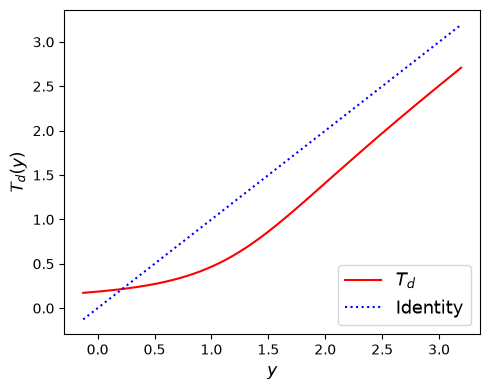

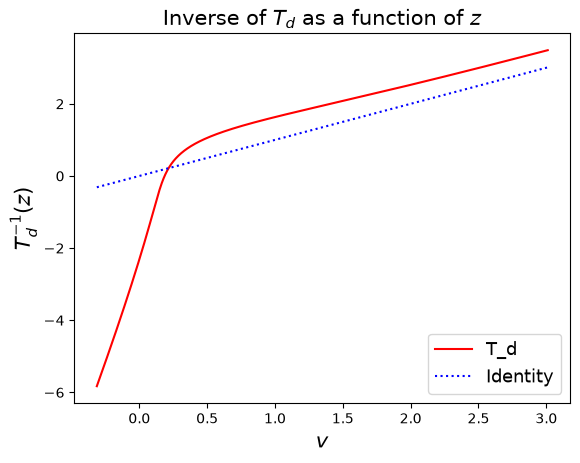

In [48]:
fig, ax = plt.subplots(figsize=(5, 4))
eval_util = Extended_glm_eval_utils()
X_tensor = torch.tensor(np.array(insurance_data), dtype=torch.float32, device="cpu")
y_tensor = torch.tensor(np.array(target), dtype=torch.float32, device="cpu")
fig, ax = eval_util.plot_nu_2(extended_glm=extended_glm, exog=X_tensor, endog=y_tensor, plot_identity=True, legend=True,
                              fig=fig, ax=ax, label="$T_d$")
ax.set_ylabel("$T_d(y)$", fontsize=12)
ax.set_xlabel("$y$", fontsize=12)
ax.set_title("", fontsize=16)
fig.tight_layout()
fig.savefig(f"{output_folder}insurance_T_d_plot.pdf")

fig, ax = eval_util.plot_nu_2(extended_glm=extended_glm, exog=X_tensor, endog=y_tensor, plot_identity=True, legend=True,
                              direction="inverse")
fig.savefig(f"{output_folder}insurance_T_d_inverse_plot.pdf")

<Axes: ylabel='Density'>

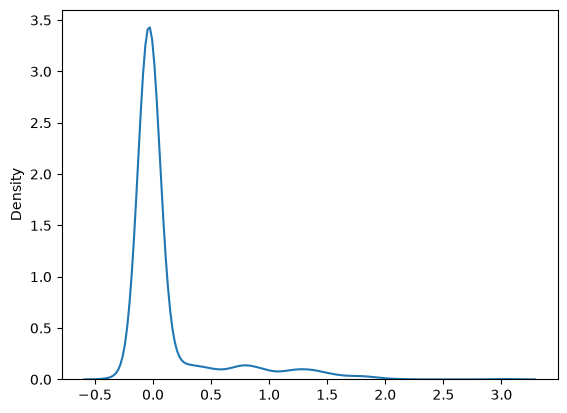

In [11]:
# we again plot the residuals:
# we do a kernel density estimator plot of the residuals:
residuals = np.array(target)-extended_glm.predict_endog(torch.tensor(np.array(insurance_data), dtype=torch.float32, device = extended_glm.used_device)).detach().cpu().numpy().reshape(-1)
sns.kdeplot(residuals)

In [45]:
estimated_variance = np.sum(residuals**2)/len(residuals-9)
print(estimated_variance)

0.167901614231767


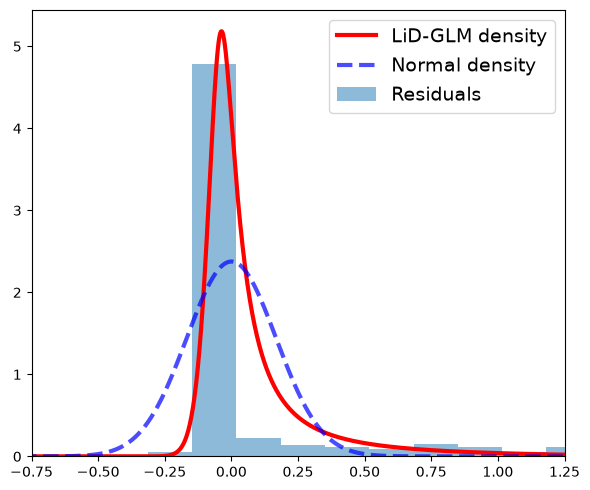

In [47]:
extended_glm.eval()
fig, ax = plt.subplots(figsize=(6, 5))
final_mean = extended_glm.predict_endog(torch.ones_like(X_tensor)).mean().item()
residuals = np.array(target)-extended_glm.predict_endog(torch.tensor(np.array(insurance_data), dtype=torch.float32, device = extended_glm.used_device)).detach().cpu().numpy().reshape(-1)
normal_residuals = np.array(target)-sm_results.predict(sm.add_constant(np.array(insurance_data), prepend=True))
y_range = torch.linspace(-1, 2, 1000)
likels = extended_glm.log_like_obs(endog=y_range+final_mean, exog = torch.ones((len(y_range), X_tensor.shape[1])), evaluation=True)
likels = np.exp(likels.detach().numpy())

# for comparison: the conditional distribution learned by the GLM
sigma = sm_results.scale
normal_dist = norm.pdf(y_range, 0, estimated_variance)

#sns.kdeplot(residuals+extended_glm.predict_endog(torch.ones_like(X_tensor)).mean().item(), ax=ax)
ax.plot(y_range, likels, color="red", linewidth=3, label="LiD-GLM density")
ax.plot(y_range, normal_dist, color="blue", linewidth=3, label="Normal density", linestyle="--", alpha=0.7)
ax.hist(residuals, bins = 20, density=True, alpha=0.5, label="Residuals")
#ax.hist(normal_residuals, bins = 20, density=True, alpha=0.5, label="Residuals")
#ax.axvline(0, color="black", linestyle="--", linewidth=2, alpha=0.5, label = "Conditional mean")
ax.set_xlim(-0.75,1.25)
ax.legend(fontsize=14)
fig.tight_layout()
fig.savefig(f"{output_folder}insurance_conditional_distr.pdf")

In [13]:
coeff_table = eval_util.coefficient_table(extended_glm=extended_glm, exog=X_tensor,
                                          coefficient_names=["bias"] + list(insurance_data.columns), original_glm=sm_results)
coeff_table.to_csv(f"{output_folder}InsuranceCoefficientTable.csv")
coeff_table

,LM,LiD-GLM,LiD-GLM with PHO,1-dim R-sq.
bias,-1.23,-1.21,-1.45,NaN
age,0.31,1.46,0.31,0.97
sex,-0.00,0.03,0.01,1.00
bmi,0.03,0.08,0.03,1.00
children,0.05,0.09,0.05,1.00
smoker,1.95,2.90,1.82,0.92
region_northwest,-0.07,-0.36,-0.02,0.77
region_southeast,-0.13,-0.48,-0.05,0.92
region_southwest,-0.09,-0.44,-0.04,0.90
